# Path-signature volatility forecasting — small, stable experiments across all horizons

This notebook evaluates **5-minute, 1-hour, 1-day, 7-day, and 30-day volatility forecasts** with a consistent, time-ordered design.

The goals are:

1. compare HAR, summary statistics, path signatures, XGBoost, MLP, and a signature LSTM;
2. isolate whether signature level, path augmentation, and path dimensions improve forecasts;
3. show *when* each model helps through timestamped out-of-sample predictions;
4. keep memory use low enough for a laptop.

The notebook uses **two purged expanding-window folds**. A training row is removed when its future volatility target reaches into the validation block. Every reported prediction is therefore out of sample. Configuration diagnostics use Ridge only so that a representation change is not confused with a simultaneous model change.

The default run limits data volume without weakening the models. It processes Binance files one day at a time, caps each horizon at 1,200 observations, retains the original signature resolution and model capacity, trains neural networks for 200 epochs, and clears objects after every horizon.


## 1. Setup

Keep this notebook in the same folder as `forecast_data.py` and `models_and_metrics.py`.

If needed, install dependencies once:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels xgboost torch arch iisignature yfinance pyarrow requests
```


In [14]:
from pathlib import Path
from dataclasses import replace
import gc
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

import forecast_data as fd
from forecast_data import (
    EPS, SPECS, ForecastDataset, build_dataset, duration_steps,
    load_or_download_yahoo,
)
from models_and_metrics import (
    evaluate_har_log, fit_mlp, fit_signature_lstm,
    fit_signature_ridge, fit_xgb,
)

warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)
np.random.seed(42)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")


## 2. Small-run configuration

The date ranges and strides control runtime more effectively than taking a random sample after feature generation. Samples remain chronological.

- The 5-minute run uses four Binance days and samples one forecast every five minutes.
- The 1-hour run uses ten Binance days and samples one forecast every 30 minutes.
- Daily horizons use every second day and retain at most the latest 1,200 examples.
- `N_SPLITS=2` means two expanding validation periods per horizon.


In [15]:
DATA_ROOT = Path("data")
OUTPUT_ROOT = Path("outputs_small")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

HORIZONS = ["5m", "1h", "1d", "7d", "30d"]
LABELS = {"5m": "5 min", "1h": "1 hour", "1d": "1 day", "7d": "7 day", "30d": "30 day"}

BINANCE_SYMBOL = "BTCUSDT"
BINANCE_RANGES = {
    "5m": ("2026-06-01", "2026-08-04"),
    "1h": ("2026-06-01", "2026-08-10"),
}
YAHOO_TICKER = "BTC-USD"
YAHOO_START, YAHOO_END = "2021-01-01", "2026-09-16"

N_SPLITS = 2
MAX_SAMPLES = 1_200
TORCH_EPOCHS = 200
WEIGHT_DECAY = {"5m": 1e-4, "1h": 1e-4, "1d": 1e-4, "7d": 5e-4, "30d": 1e-3}
FORCE_DOWNLOAD = False
DELETE_RAW_TRADE_CACHE = True  # raw daily trade parquet files are huge and reproducible

# Fewer sampled paths lower runtime; path resolution matches the original notebook.
SMALL_SPEC_OVERRIDES = {
    "5m":  dict(sample_stride=60, path_points=64),
    "1h":  dict(sample_stride=30, path_points=96),
    "1d":  dict(sample_stride=2),
    "7d":  dict(sample_stride=2),
    "30d": dict(sample_stride=2),
}

# Four or six sequence steps make the LSTM a real sequence model at every horizon.
LSTM_SUB_WINDOW = {"5m": "30min", "1h": "6h", "1d": "5D", "7d": "5D", "30d": "5D"}


## 3. Data and evaluation helpers

The Binance loader aggregates each raw trade day immediately, so several days of tick data are never held in memory together. `cap_dataset` keeps the latest observations without changing their order.

The purge condition is:

\[
	ext{target end of training row} < 	ext{first validation forecast time}.
\]

This prevents a training label from using returns that occur during the validation block.


In [16]:
_BARS = {}

def load_binance_bars_compat(start, end, freq, symbol, data_dir, force_download=False):
    # Stream one raw day at a time. Raw trades are never written to disk.
    # Existing raw caches are consumed and removed after resampling.
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    daily_bars = []
    for day in fd._inclusive_dates(start, end):
        day_str = day.strftime("%Y-%m-%d")
        path = data_dir / f"{symbol}_trades_{day_str}.parquet"
        raw = None
        if path.exists() and not force_download:
            try:
                raw = pd.read_parquet(path)
            except Exception:
                # A previous disk-full error may have left a partial parquet file.
                path.unlink(missing_ok=True)
        if raw is None:
            try:
                raw = fd._download_one_binance_day(symbol, day)
            except FileNotFoundError as exc:
                print(f"Skipping {day_str}: {exc}")
                continue
        trades = fd.prepare_binance_trades(raw)
        daily_bars.append(fd.binance_to_bars(trades, freq))
        if DELETE_RAW_TRADE_CACHE and path.exists():
            path.unlink()
        del raw, trades
        gc.collect()
    if not daily_bars:
        raise ValueError("No Binance data was available for the requested dates.")
    bars = pd.concat(daily_bars).sort_index()
    return bars.loc[~bars.index.duplicated(keep="last")]

def small_spec(horizon, **changes):
    return replace(SPECS[horizon], **SMALL_SPEC_OVERRIDES[horizon], **changes)


def get_bars(horizon):
    if horizon in _BARS:
        return _BARS[horizon]
    if horizon in {"5m", "1h"}:
        start, end = BINANCE_RANGES[horizon]
        bars = load_binance_bars_compat(
            start, end, freq=SPECS[horizon].bar_freq,
            symbol=BINANCE_SYMBOL, data_dir=DATA_ROOT / "binance",
            force_download=FORCE_DOWNLOAD,
        )
    else:
        bars = load_or_download_yahoo(
            YAHOO_START, YAHOO_END, ticker=YAHOO_TICKER,
            data_dir=DATA_ROOT / "yahoo", force_download=FORCE_DOWNLOAD,
        )
    _BARS.clear()                 # only one horizon's bars stay in memory
    _BARS[horizon] = bars
    return bars


def cap_dataset(d, n=MAX_SAMPLES):
    if len(d.y) <= n:
        return d
    ix = np.arange(len(d.y) - n, len(d.y))
    return ForecastDataset(
        times=d.times[ix], target_end=d.target_end[ix], y=d.y[ix],
        X_har=d.X_har[ix], X_stats=d.X_stats[ix], X_sig=d.X_sig[ix],
        har_names=d.har_names, stat_names=d.stat_names,
        y_har_log=d.y_har_log[ix],
        X_seq=None if d.X_seq is None else d.X_seq[ix],
    )


def make_dataset(horizon, spec, include_seq=False):
    d = build_dataset(
        get_bars(horizon), spec, include_lstm_seq=include_seq,
        sub_window=LSTM_SUB_WINDOW[horizon],
    )
    return cap_dataset(d)


def purged_folds(d, n_splits=N_SPLITS):
    folds = []
    for fold, (train, test) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(d.y), 1):
        first_test_time = d.times[test[0]]
        train = train[d.target_end[train] < first_test_time]
        if len(train) < 50:
            raise ValueError(f"Fold {fold} has only {len(train)} training rows after purging.")
        folds.append((fold, train, test))
    return folds


def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))


def tuned_ridge(X, y):
    # Same alpha grid and five-fold time-series tuning as the original notebook.
    return fit_signature_ridge(X, y, n_splits=5, n_jobs=1)


def original_xgb(X, y):
    # Exact original 500-tree, depth-3 XGBoost helper.
    return fit_xgb(X, y, n_jobs=1)


## 4. Main model comparison

All models receive the same folds and target. Model capacity and training length match the original notebook; the smaller run changes data volume and execution order only.

- **Mean:** no-information reference.
- **HAR-RV-L:** volatility-history baseline.
- **Ridge / XGBoost (stats):** hand-built summaries.
- **Ridge / XGBoost (signature):** path signature only.
- **Ridge / MLP (stats + signature):** tests complementary information.
- **Signature LSTM:** sequence of signatures from four or six lookback subwindows.

The model configuration is fixed before looking at these folds. Later representation diagnostics therefore explain the results; they do not retroactively select the winner in this table.


In [17]:
def run_models(horizon, d, spec):
    h = duration_steps(spec.horizon, spec.bar_freq)
    rows, predictions = [], []

    for fold, tr, te in purged_folds(d):
        ytr, yte = d.y[tr], d.y[te]
        feature_sets = {
            "Ridge | stats": d.X_stats,
            "Ridge | signature": d.X_sig,
            "Ridge | stats+signature": np.hstack([d.X_stats, d.X_sig]),
        }
        fold_preds = {}

        fold_preds["Mean"] = DummyRegressor().fit(d.X_stats[tr], ytr).predict(d.X_stats[te])

        har = evaluate_har_log(
            d.X_har[tr], d.y_har_log[tr], d.X_har[te], yte, h,
        )
        fold_preds["HAR-RV-L"] = har.predictions

        for name, X in feature_sets.items():
            fold_preds[name] = tuned_ridge(X[tr], ytr).predict(X[te])

        for name, X in {"XGBoost | stats": d.X_stats, "XGBoost | signature": d.X_sig}.items():
            fold_preds[name] = original_xgb(X[tr], ytr).predict(X[te])

        Xboth = np.hstack([d.X_stats, d.X_sig])
        mlp = fit_mlp(
            Xboth[tr], ytr, hidden=(128, 64, 16), weight_decay=WEIGHT_DECAY[horizon],
            epochs=TORCH_EPOCHS, batch_size=64, random_state=42 + fold,
        )
        fold_preds["MLP | stats+signature"] = mlp.predict(Xboth[te])

        lstm = fit_signature_lstm(
            d.X_seq[tr], ytr, hidden=32, weight_decay=WEIGHT_DECAY[horizon],
            epochs=TORCH_EPOCHS, batch_size=64, random_state=42 + fold,
        )
        fold_preds["Signature LSTM"] = lstm.predict(d.X_seq[te])

        for name, pred in fold_preds.items():
            pred = np.maximum(np.asarray(pred), EPS)
            rows.append({
                "HorizonKey": horizon, "Horizon": LABELS[horizon],
                "Fold": fold, "Model": name, "RMSE": rmse(yte, pred),
                "N_train": len(tr), "N_test": len(te),
            })
            predictions.append(pd.DataFrame({
                "HorizonKey": horizon, "Horizon": LABELS[horizon],
                "Fold": fold, "Time": pd.to_datetime(d.times[te]),
                "Model": name, "Actual": yte, "Prediction": pred,
            }))

    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True)


## 5. Representation diagnostics

These experiments all use the same time-series-tuned Ridge model. That isolates the path representation itself while preserving the original model strength.

- **Signature level:** L1, L1–2, and L1–3.
- **Augmentation:** raw path, time, and lead-lag + time.
- **Dimensions:** price alone versus the full path.

For intraday data the full path is price + activity + signed flow. For daily data it is price + activity + high-low range.


In [18]:
def signature_level_slices(spec):
    dim = len(spec.dims) * (2 if spec.lead_lag else 1) + int(spec.time_aug)
    ends = np.cumsum([dim ** k for k in range(1, spec.depth + 1)])
    return {f"L1-{k}": slice(0, int(end)) for k, end in enumerate(ends, 1)}


def ridge_oos_rows(horizon, d, X, group, setting):
    out = []
    for fold, tr, te in purged_folds(d):
        pred = np.maximum(tuned_ridge(X[tr], d.y[tr]).predict(X[te]), EPS)
        out.append({
            "HorizonKey": horizon, "Horizon": LABELS[horizon], "Fold": fold,
            "Experiment": group, "Setting": setting, "RMSE": rmse(d.y[te], pred),
        })
    return out


def run_diagnostics(horizon, base, spec):
    rows = []

    for setting, sl in signature_level_slices(spec).items():
        rows += ridge_oos_rows(horizon, base, base.X_sig[:, sl], "Signature level", setting)

    # Full configuration reuses the already-built base dataset.
    rows += ridge_oos_rows(horizon, base, base.X_sig, "Augmentation", "Lead-lag + time")
    for setting, kwargs in {
        "None": dict(lead_lag=False, time_aug=False),
        "Time": dict(lead_lag=False, time_aug=True),
    }.items():
        d = make_dataset(horizon, replace(spec, **kwargs), include_seq=False)
        rows += ridge_oos_rows(horizon, d, d.X_sig, "Augmentation", setting)
        del d
        gc.collect()

    rows += ridge_oos_rows(horizon, base, base.X_sig, "Dimensions", "Full path")
    d = make_dataset(horizon, replace(spec, dims=("price",)), include_seq=False)
    rows += ridge_oos_rows(horizon, d, d.X_sig, "Dimensions", "Price only")
    del d
    gc.collect()

    return pd.DataFrame(rows)


## 6. Run all five horizons

This is the only long-running cell. Each horizon is built, evaluated, summarized, and deleted before the next horizon begins. If a run is interrupted, completed horizons are saved as CSV files in `outputs_small`.


In [19]:
all_metrics, all_predictions, all_diagnostics = [], [], []

for horizon in HORIZONS:
    print(f"\n[{LABELS[horizon]}] building compact dataset ...")
    spec = small_spec(horizon, depth=3, lead_lag=True, time_aug=True)
    d = make_dataset(horizon, spec, include_seq=True)
    print(
        f"  n={len(d.y):,} | stats={d.X_stats.shape[1]} | "
        f"signature={d.X_sig.shape[1]} | LSTM sequence={d.X_seq.shape[1:]}"
    )

    metrics, preds = run_models(horizon, d, spec)
    diagnostics = run_diagnostics(horizon, d, spec)

    all_metrics.append(metrics)
    all_predictions.append(preds)
    all_diagnostics.append(diagnostics)

    pd.concat(all_metrics, ignore_index=True).to_csv(OUTPUT_ROOT / "model_fold_metrics.csv", index=False)
    pd.concat(all_predictions, ignore_index=True).to_csv(OUTPUT_ROOT / "oos_predictions.csv", index=False)
    pd.concat(all_diagnostics, ignore_index=True).to_csv(OUTPUT_ROOT / "configuration_diagnostics.csv", index=False)

    display(
        metrics.groupby("Model")["RMSE"].agg(["mean", "std"])
        .sort_values("mean").style.format("{:.6g}")
        .set_caption(f"{LABELS[horizon]} — purged out-of-sample RMSE")
    )

    del d, metrics, preds, diagnostics
    _BARS.clear()
    gc.collect()

model_fold_metrics = pd.concat(all_metrics, ignore_index=True)
oos_predictions = pd.concat(all_predictions, ignore_index=True)
configuration_diagnostics = pd.concat(all_diagnostics, ignore_index=True)



[5 min] building compact dataset ...
  n=1,200 | stats=11 | signature=399 | LSTM sequence=(4, 399)


,mean,std
Model,,
Ridge | stats,0.000397237,1.33075e-05
HAR-RV-L,0.000415471,7.42744e-05
Ridge | stats+signature,0.00042688,1.5095e-05
Ridge | signature,0.00044262,2.77346e-05
XGBoost | signature,0.000486623,1.41891e-05
XGBoost | stats,0.000486623,1.41891e-05
Mean,0.000486623,1.41892e-05
MLP | stats+signature,0.000635848,0.000244915
Signature LSTM,0.00900845,0.0113606



[1 hour] building compact dataset ...
  n=1,200 | stats=11 | signature=399 | LSTM sequence=(4, 399)


,mean,std
Model,,
HAR-RV-L,0.00108302,0.000204358
Ridge | stats,0.00131067,0.000202137
Ridge | stats+signature,0.00139607,0.000233293
XGBoost | stats,0.00140732,0.000255431
XGBoost | signature,0.00142759,0.000226761
Ridge | signature,0.00143042,0.000210621
Mean,0.00146823,0.000169297
MLP | stats+signature,0.00178887,0.000607032
Signature LSTM,0.00763314,0.00791982



[1 day] building compact dataset ...
  n=1,028 | stats=11 | signature=399 | LSTM sequence=(6, 399)


,mean,std
Model,,
Ridge | stats+signature,0.0116822,0.00112336
Ridge | signature,0.0116932,0.00120166
XGBoost | signature,0.0120777,0.00117652
HAR-RV-L,0.0122434,0.000569923
MLP | stats+signature,0.0123203,0.00171889
Ridge | stats,0.0124184,0.000247587
XGBoost | stats,0.0131113,0.000240227
Mean,0.0151383,0.00216439
Signature LSTM,0.0179932,0.00691526



[7 day] building compact dataset ...
  n=1,025 | stats=11 | signature=399 | LSTM sequence=(6, 399)


,mean,std
Model,,
Ridge | signature,0.0218527,0.00241215
Ridge | stats+signature,0.0223016,0.00123864
HAR-RV-L,0.0229474,0.00110635
MLP | stats+signature,0.0229545,0.00126995
XGBoost | signature,0.0243339,0.00208984
Ridge | stats,0.0252722,0.00626206
Signature LSTM,0.0267474,0.00173671
Mean,0.0314512,0.00614895
XGBoost | stats,0.0319462,0.00368652



[30 day] building compact dataset ...
  n=1,013 | stats=11 | signature=399 | LSTM sequence=(6, 399)


,mean,std
Model,,
Ridge | signature,0.0439738,0.0125247
HAR-RV-L,0.0444623,0.00746122
Signature LSTM,0.0462696,0.00277013
XGBoost | signature,0.0467325,0.0136422
Ridge | stats+signature,0.0477974,0.00551254
Mean,0.0594911,0.0175321
Ridge | stats,0.0610486,0.0199716
XGBoost | stats,0.0642141,0.0147376
MLP | stats+signature,0.0725518,0.0275793


## 7. Visual 1 — performance relative to the mean forecast

Raw volatility RMSE is not comparable across horizons. This heatmap converts each score to percentage improvement over the mean forecast for the same horizon:

\[
100\left(1-
rac{\mathrm{RMSE}_{model}}{\mathrm{RMSE}_{mean}}
ight).
\]

Positive values are improvements. Negative values mean the model performed worse than predicting the training mean.


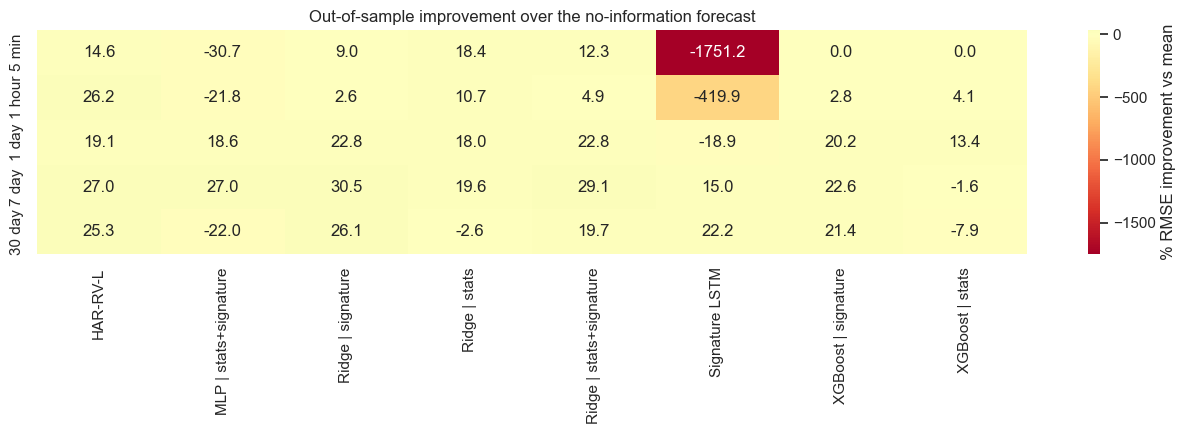

In [20]:
mean_rmse = (
    model_fold_metrics.groupby(["Horizon", "Model"])["RMSE"].mean().unstack()
    .reindex([LABELS[h] for h in HORIZONS])
)
relative = 100 * (1 - mean_rmse.div(mean_rmse["Mean"], axis=0))

plt.figure(figsize=(13, 4.5))
sns.heatmap(relative.drop(columns="Mean"), annot=True, fmt=".1f", center=0,
            cmap="RdYlGn", cbar_kws={"label": "% RMSE improvement vs mean"})
plt.title("Out-of-sample improvement over the no-information forecast")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 8. Visual 2 — fold stability

A model is more convincing when it improves both validation periods. The plot below scales every fold by that fold's mean-forecast RMSE, so values below 1 are better than the no-information reference.


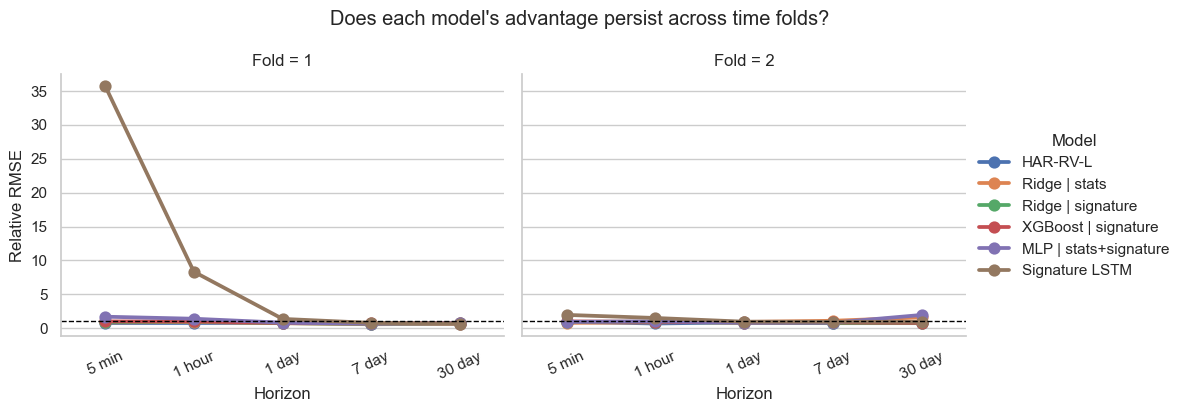

In [21]:
fold_plot = model_fold_metrics.copy()
baseline = fold_plot[fold_plot.Model.eq("Mean")][["Horizon", "Fold", "RMSE"]].rename(columns={"RMSE": "MeanRMSE"})
fold_plot = fold_plot.merge(baseline, on=["Horizon", "Fold"])
fold_plot["Relative RMSE"] = fold_plot["RMSE"] / fold_plot["MeanRMSE"]

models_to_show = ["HAR-RV-L", "Ridge | stats", "Ridge | signature",
                  "XGBoost | signature", "MLP | stats+signature", "Signature LSTM"]
g = sns.catplot(
    data=fold_plot[fold_plot.Model.isin(models_to_show)], x="Horizon", y="Relative RMSE",
    hue="Model", col="Fold", kind="point", height=4, aspect=1.25,
)
for ax in g.axes.flat:
    ax.axhline(1, color="black", ls="--", lw=1)
    ax.tick_params(axis="x", rotation=25)
g.fig.subplots_adjust(top=.82)
g.fig.suptitle("Does each model's advantage persist across time folds?")
plt.show()


## 9. Visual 3 — actual and predicted volatility through time

For each horizon, this selects the model with the lowest average fold RMSE and compares it with HAR-RV-L. This shows whether gains come from tracking ordinary changes, capturing spikes, or simply smoothing the target.


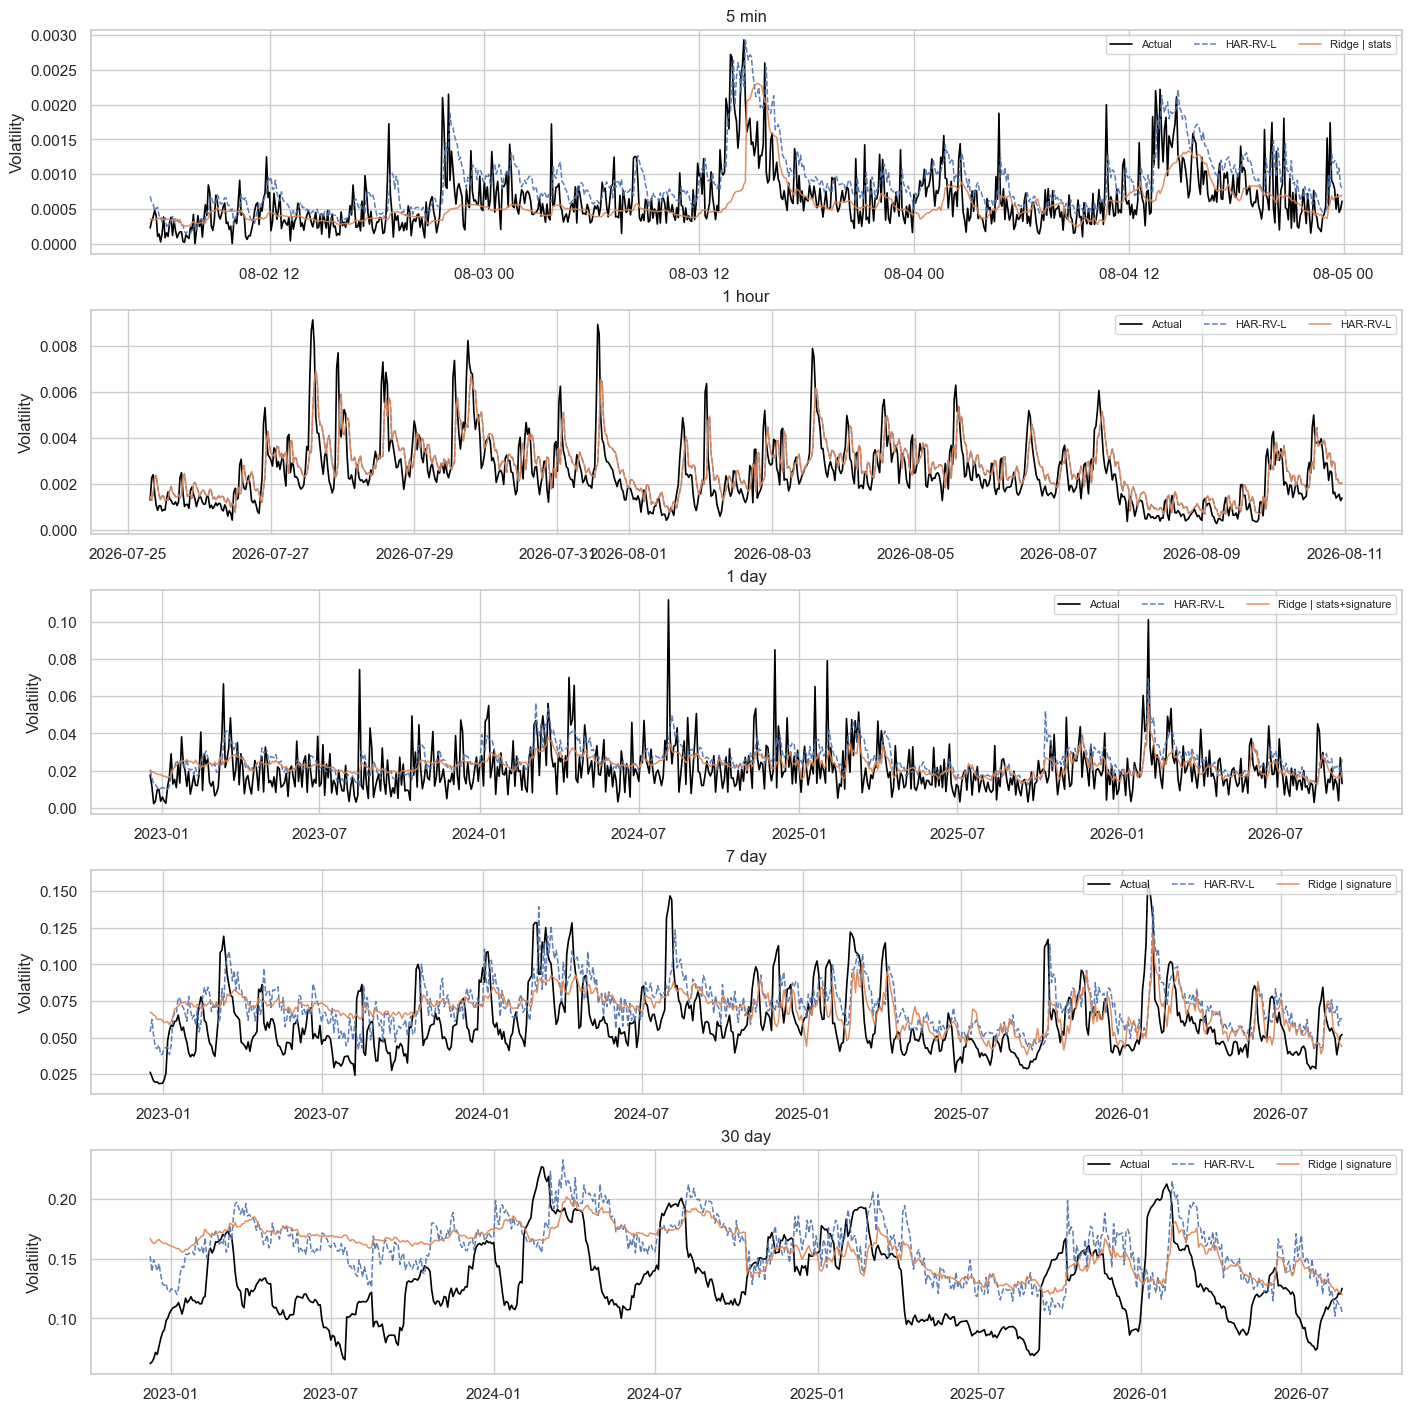

In [22]:
avg = model_fold_metrics.groupby(["Horizon", "Model"])["RMSE"].mean().reset_index()
best = avg.loc[avg.groupby("Horizon")["RMSE"].idxmin(), ["Horizon", "Model"]]
best_map = dict(zip(best.Horizon, best.Model))

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 14), constrained_layout=True)
for ax, key in zip(axes, HORIZONS):
    hz = LABELS[key]
    sub = oos_predictions[oos_predictions.Horizon.eq(hz)]
    actual = sub.drop_duplicates(["Time"])[["Time", "Actual"]].sort_values("Time")
    ax.plot(actual.Time, actual.Actual, color="black", lw=1.2, label="Actual")
    for model, style in [("HAR-RV-L", "--"), (best_map[hz], "-")]:
        p = sub[sub.Model.eq(model)].sort_values("Time")
        ax.plot(p.Time, p.Prediction, lw=1.1, ls=style, label=model, alpha=.9)
    ax.set_title(hz)
    ax.set_ylabel("Volatility")
    ax.legend(loc="upper right", ncol=3, fontsize=8)
plt.show()


## 10. Visual 4 — when the best model gains or loses against HAR

The curve accumulates `HAR squared error − best-model squared error`. An upward segment means the selected model is adding value during that period; a downward segment means HAR is doing better.


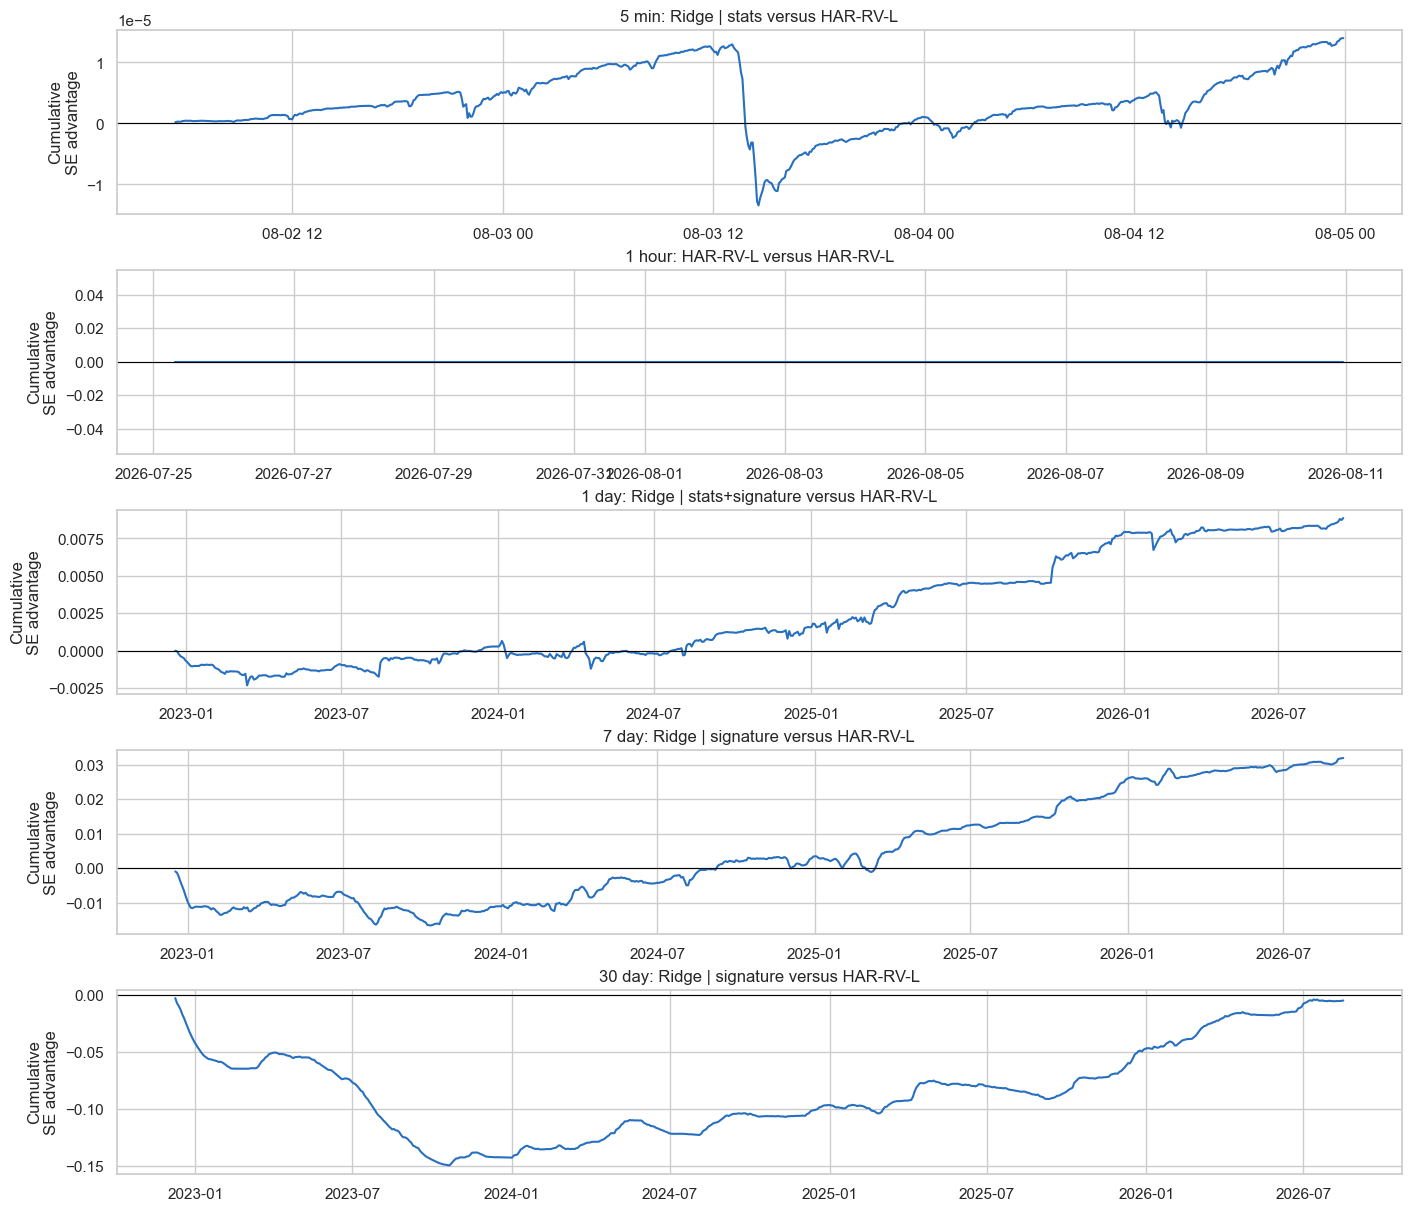

In [23]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 12), constrained_layout=True)
for ax, key in zip(axes, HORIZONS):
    hz = LABELS[key]
    winner = best_map[hz]
    sub = oos_predictions[oos_predictions.Horizon.eq(hz)]
    h = sub[sub.Model.eq("HAR-RV-L")][["Time", "Actual", "Prediction"]].rename(columns={"Prediction": "HAR"})
    b = sub[sub.Model.eq(winner)][["Time", "Prediction"]].rename(columns={"Prediction": "Best"})
    z = h.merge(b, on="Time").sort_values("Time")
    z["Cumulative advantage"] = ((z.Actual-z.HAR)**2 - (z.Actual-z.Best)**2).cumsum()
    ax.plot(z.Time, z["Cumulative advantage"], color="#276FBF")
    ax.axhline(0, color="black", lw=.8)
    ax.set_title(f"{hz}: {winner} versus HAR-RV-L")
    ax.set_ylabel("Cumulative\nSE advantage")
plt.show()


## 11. Visual 5 — performance by realized-volatility regime

Regimes are defined from the out-of-sample target within each horizon: low, middle, and high realized volatility. This is a descriptive diagnostic, not an input to the model. It reveals whether a model's average advantage comes mainly from calm periods or volatility spikes.


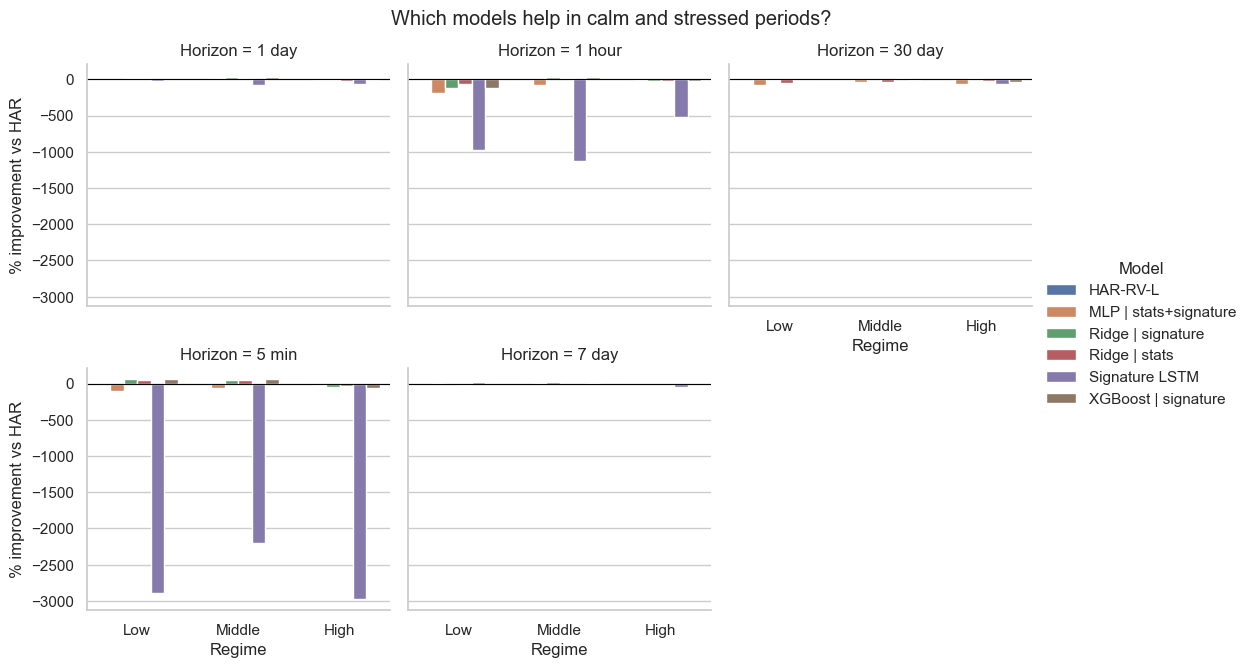

In [24]:
reg = oos_predictions.copy()
reg["Regime"] = reg.groupby("Horizon")["Actual"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=["Low", "Middle", "High"])
)
reg["SquaredError"] = (reg.Actual - reg.Prediction) ** 2
reg_rmse = np.sqrt(reg.groupby(["Horizon", "Model", "Regime"], observed=True).SquaredError.mean()).reset_index(name="RMSE")
reg_base = reg_rmse[reg_rmse.Model.eq("HAR-RV-L")][["Horizon", "Regime", "RMSE"]].rename(columns={"RMSE":"HAR_RMSE"})
reg_rmse = reg_rmse.merge(reg_base, on=["Horizon", "Regime"])
reg_rmse["% improvement vs HAR"] = 100 * (1 - reg_rmse.RMSE / reg_rmse.HAR_RMSE)

show = reg_rmse[reg_rmse.Model.isin(models_to_show)].copy()
g = sns.catplot(data=show, x="Regime", y="% improvement vs HAR", hue="Model",
                col="Horizon", col_wrap=3, kind="bar", height=3.4, aspect=1.05)
for ax in g.axes.flat:
    ax.axhline(0, color="black", lw=.8)
g.fig.subplots_adjust(top=.9)
g.fig.suptitle("Which models help in calm and stressed periods?")
plt.show()


## 12. Visual 6 — what in the signature configuration drives performance?

Each panel reports Ridge RMSE relative to a simple reference in the same experiment:

- signature levels are compared with L1;
- augmentations are compared with no augmentation;
- dimensions are compared with price only.

Positive values indicate lower RMSE than the reference. Because the learner is fixed, differences come from the representation.


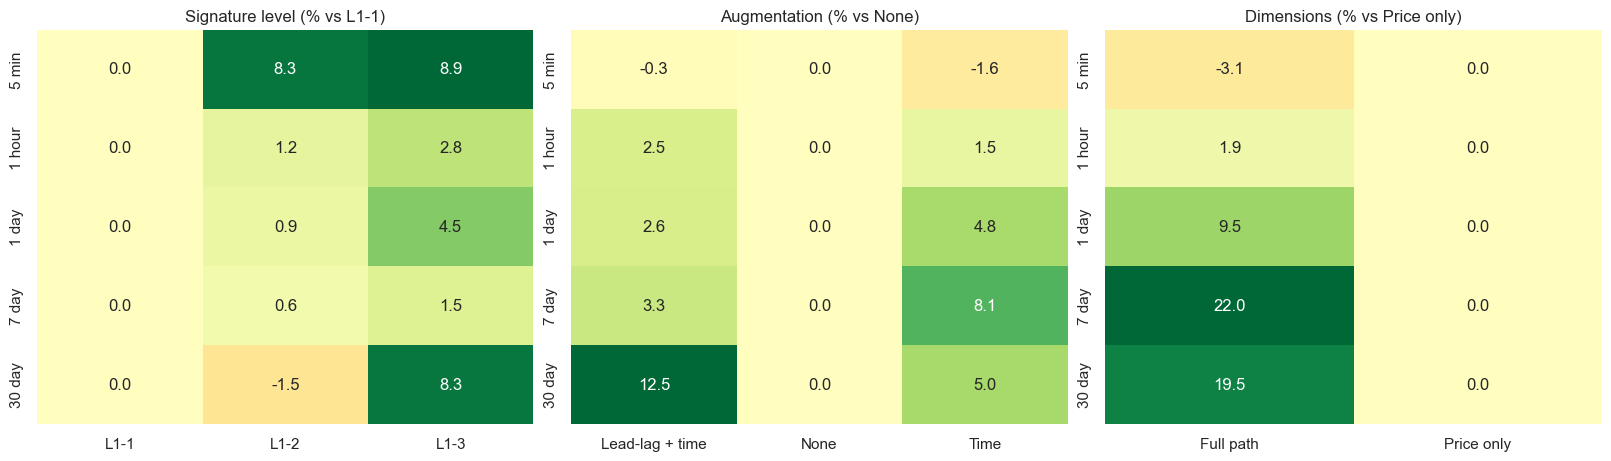

In [25]:
diag = configuration_diagnostics.groupby(["Horizon", "Experiment", "Setting"])["RMSE"].mean().reset_index()
controls = {"Signature level": "L1-1", "Augmentation": "None", "Dimensions": "Price only"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (experiment, control) in zip(axes, controls.items()):
    z = diag[diag.Experiment.eq(experiment)].copy()
    base = z[z.Setting.eq(control)][["Horizon", "RMSE"]].rename(columns={"RMSE":"ControlRMSE"})
    z = z.merge(base, on="Horizon")
    z["Improvement"] = 100 * (1 - z.RMSE / z.ControlRMSE)
    mat = z.pivot(index="Horizon", columns="Setting", values="Improvement").reindex([LABELS[h] for h in HORIZONS])
    sns.heatmap(mat, annot=True, fmt=".1f", center=0, cmap="RdYlGn", ax=ax,
                cbar=False)
    ax.set_title(experiment + f" (% vs {control})")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()


## 13. Compact conclusions table and saved outputs

Use this table to separate three claims:

1. **Model effect:** which learner has the lowest out-of-sample RMSE?
2. **Feature effect:** do signatures improve upon statistics for the same learner?
3. **Configuration effect:** which signature construction improves fixed-Ridge forecasts consistently across folds?

Two folds and a capped dataset are appropriate for debugging and directional analysis. Once the notebook runs reliably, increase the dates, `MAX_SAMPLES`, and `N_SPLITS` to confirm the conclusions. Do not choose a configuration from this run and describe its same-fold score as a final untouched test result.


In [26]:
summary = (
    model_fold_metrics.groupby(["Horizon", "Model"])["RMSE"]
    .agg(Mean_RMSE="mean", Fold_SD="std").reset_index()
)
summary["Rank"] = summary.groupby("Horizon")["Mean_RMSE"].rank(method="dense")
summary = summary.sort_values(["Horizon", "Rank"])
display(summary.style.format({"Mean_RMSE":"{:.6g}", "Fold_SD":"{:.6g}", "Rank":"{:.0f}"}))

summary.to_csv(OUTPUT_ROOT / "model_summary.csv", index=False)
print(f"Saved metrics, predictions, diagnostics, and summary to {OUTPUT_ROOT.resolve()}")


,Horizon,Model,Mean_RMSE,Fold_SD,Rank
5,1 day,Ridge | stats+signature,0.0116822,0.00112336,1
3,1 day,Ridge | signature,0.0116932,0.00120166,2
7,1 day,XGBoost | signature,0.0120777,0.00117652,3
0,1 day,HAR-RV-L,0.0122434,0.000569923,4
1,1 day,MLP | stats+signature,0.0123203,0.00171889,5
4,1 day,Ridge | stats,0.0124184,0.000247587,6
8,1 day,XGBoost | stats,0.0131113,0.000240227,7
2,1 day,Mean,0.0151383,0.00216439,8
6,1 day,Signature LSTM,0.0179932,0.00691526,9
9,1 hour,HAR-RV-L,0.00108302,0.000204358,1


Saved metrics, predictions, diagnostics, and summary to /Users/mihikaghaisas/Desktop/CMU/MLCapstone/Mihika/outputs_small
